# 05 -- Hypothetical Event-Driven Backtest

> **WARNING**: All results in this notebook are **hypothetical** and presented
> solely to assess prediction signal quality. They assume zero transaction costs,
> perfect fills at closing prices, and equal-weight positions.
> They are NOT a forecast of real-world profitability and should NOT be
> used as the basis for actual investment decisions.

## Strategy Logic
| Phase | Action |
|-------|--------|
| Prediction date (ann - 14 td) | Buy predicted additions at close |
| Announcement date | Confirm/reject: keep confirmed, sell rejected at close |
| Effective date + 1 | Sell confirmed positions at close |

## Data Flow
Stage 4 synthetic data is reused. Prediction model (top_k selected on train set) is applied here.


In [1]:
import sys, logging
from pathlib import Path
import functools

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

sys.path.insert(0, str(Path("../src").resolve()))

from prediction import (
    predict_additions,
    predict_full_constituents,
    backtest_predictions,
    DEFAULT_TOP_K,
    _last_value_before,
    _compute_avg_turnover,
)
from backtest import (
    generate_signals,
    generate_signals_long_short,
    compute_trade_returns,
    compute_directional_returns,
    aggregate_event_returns,
    aggregate_long_short_event_returns,
    compute_strategy_metrics,
    compute_max_drawdown,
    compute_holding_periods,
    compute_benchmark_event_returns,
    plot_cumulative_return,
    plot_strategy_vs_benchmark,
    plot_risk_breakdown,
    plot_parameter_sensitivity,
)

logging.basicConfig(level=logging.INFO,
                    format="%(asctime)s [%(levelname)s] %(name)s -- %(message)s")

FIG_DIR   = Path("../output/figures")
TABLE_DIR = Path("../output/tables")
FIG_DIR.mkdir(parents=True, exist_ok=True)
TABLE_DIR.mkdir(parents=True, exist_ok=True)


## 1. Reconstruct Stage-4 Data and Determine best_k

In [2]:
# ════════════════════════════════════════════════════════════════
# ⛔  DEPRECATED — 此 cell 產生合成資料，禁止在真實研究中執行
# ════════════════════════════════════════════════════════════════
raise RuntimeError(
    "合成資料已停用。請先建立真實資料 (data/raw/events.csv + "
    "data/processed/stock_prices.parquet) 再執行本 notebook。"
)

# ── 以下為原合成資料程式碼，僅供參考 ──
def _make_stage4_data():
    """Same generator as notebook 04."""
    rng = np.random.default_rng(seed=99)
    trading_days = pd.bdate_range("2020-01-01", "2024-12-31")
    n = len(trading_days)
    sids = [f"S{i:03d}" for i in range(1, 31)]
    base_shares = {sid: max(5e8, 1e10 / (1 + int(sid[1:]) ** 0.8)) for sid in sids}
    vol_map     = {sid: 0.008 + 0.018 * int(sid[1:]) / 30 for sid in sids}
    base_yield  = {sid: 2.0 + 6.0 * int(sid[1:]) / 30 for sid in sids}

    taiex_rets = rng.normal(0.0002, 0.006, size=n - 1)
    taiex_px   = np.concatenate([[17500.0], 17500.0 * np.cumprod(1 + taiex_rets)])
    base_rets  = {sid: rng.normal(0.0001, vol_map[sid], size=n - 1) for sid in sids}

    raw_events = [
        dict(id=1,  ann="2020-05-13", eff="2020-05-20", added=["S001","S003","S005"],       removed=["S021","S022"]),
        dict(id=2,  ann="2020-12-09", eff="2020-12-16", added=["S002","S007"],               removed=["S023"]),
        dict(id=3,  ann="2021-05-12", eff="2021-05-19", added=["S004","S009","S011"],        removed=["S024","S025"]),
        dict(id=4,  ann="2021-12-08", eff="2021-12-15", added=["S006","S013"],               removed=["S001"]),
        dict(id=5,  ann="2022-05-11", eff="2022-05-18", added=["S008","S015","S017"],        removed=["S003","S026"]),
        dict(id=6,  ann="2022-12-07", eff="2022-12-14", added=["S001","S010"],               removed=["S027"]),
        dict(id=7,  ann="2023-05-10", eff="2023-05-17", added=["S012","S014","S016","S019"], removed=["S002","S004"]),
        dict(id=8,  ann="2023-12-06", eff="2023-12-13", added=["S003","S018"],               removed=["S028"]),
        dict(id=9,  ann="2024-05-08", eff="2024-05-15", added=["S020","S022","S024"],        removed=["S006","S008"]),
        dict(id=10, ann="2024-12-04", eff="2024-12-11", added=["S005","S021"],               removed=["S029"]),
        dict(id=11, ann="2023-08-09", eff="2023-08-16", added=["S023","S025"],               removed=["S011"]),
        dict(id=12, ann="2024-08-07", eff="2024-08-14", added=["S026","S027","S028"],        removed=["S013","S015"]),
    ]
    shock = {0:+0.015, 1:+0.008, 2:+0.005, 3:+0.003, **{d:-0.0015 for d in range(4,12)}}
    for ev in raw_events:
        ann = pd.Timestamp(ev["ann"])
        future = trading_days[trading_days >= ann]
        if future.empty: continue
        t0 = trading_days.get_loc(future[0])
        for sid in [s for s in ev["added"] if s in sids]:
            scale = 1 + 0.3 * int(sid[1:]) / 30
            for offset, s in shock.items():
                idx = t0 + offset
                if 0 <= idx < len(base_rets[sid]):
                    base_rets[sid][idx] += s * scale

    all_px = {"TAIEX": np.concatenate([[17500.0], 17500.0 * np.cumprod(1 + taiex_rets)])}
    for sid in sids:
        all_px[sid] = np.concatenate([[100.0], 100.0 * np.cumprod(1 + base_rets[sid])])
    prices_wide = pd.DataFrame(all_px, index=trading_days)
    prices_wide.index.name = "date"

    turnover_wide = pd.DataFrame(
        {sid: prices_wide[sid].values *
              rng.integers(int(5e5/(1+int(sid[1:])/30)), int(5e6/(1+int(sid[1:])/60)+1), size=n)
         for sid in sids}, index=trading_days)
    turnover_wide.index.name = "date"

    shares_records = []
    for q_date in pd.date_range("2020-01-01", "2024-12-31", freq="QS-MAR"):
        for sid in sids:
            shares_records.append({"date": q_date, "stock_id": sid,
                                    "shares_issued": base_shares[sid] * rng.uniform(0.98, 1.02)})
    shares_df = pd.DataFrame(shares_records).set_index("date").sort_index()

    per_records = []
    for day in trading_days:
        for sid in sids:
            per_records.append({"date": day, "stock_id": sid,
                                 "dividend_yield": max(0.3, base_yield[sid] + rng.normal(0, 0.4)),
                                 "PER": rng.uniform(8,30), "PBR": rng.uniform(0.8,4)})
    per_df = pd.DataFrame(per_records).set_index("date").sort_index()

    event_rows = []
    for ev in raw_events:
        event_rows.append({
            "event_id": ev["id"], "etf_code": "00919",
            "announcement_date": pd.Timestamp(ev["ann"]),
            "effective_date":    pd.Timestamp(ev["eff"]),
            "added_stocks":   [s for s in ev["added"]   if s in sids],
            "removed_stocks": [s for s in ev["removed"] if s in sids],
        })
    return (prices_wide, turnover_wide, shares_df, per_df,
            pd.DataFrame(event_rows).sort_values("announcement_date").reset_index(drop=True))


In [3]:
prices_wide, turnover_wide, shares_df, per_df, events = _make_stage4_data()
events_sorted = events.sort_values("announcement_date").reset_index(drop=True)

# Replicate train/test split from notebook 04 to get best_k
n_events = len(events_sorted)
n_train  = max(2, int(np.ceil(n_events * 0.6)))
train_event_ids = set(events_sorted.iloc[:n_train]["event_id"].tolist())

PRED_OFFSET = -14
CANDIDATE_K = [1, 2, 3, 5, 8, 10, 15]
k_f1 = {}
for k in CANDIDATE_K:
    bt = backtest_predictions(
        events=events_sorted, prices_wide=prices_wide,
        per_df=per_df, turnover_wide=turnover_wide, shares_df=shares_df,
        prediction_date_offset=PRED_OFFSET, top_k=k,
    )
    train_f1 = bt[bt["event_id"].isin(train_event_ids)]["f1"].mean()
    k_f1[k] = train_f1

best_k = max(k_f1, key=k_f1.get)
print(f"best_k = {best_k}  (train F1 = {k_f1[best_k]:.3f})")


2026-05-17 22:51:34,641 [WARNING] prediction -- Empty eligible universe at 2020-04-23
2026-05-17 22:51:34,642 [INFO] prediction -- Event 1  pred=2020-04-23  ann=2020-05-13  precision=0.00  recall=0.00
2026-05-17 22:51:34,657 [INFO] prediction -- December review: estimated yield approximated as trailing yield (YTD EPS growth data not available).
2026-05-17 22:51:34,698 [INFO] prediction -- Event 2  pred=2020-11-19  ann=2020-12-09  precision=0.00  recall=0.00
2026-05-17 22:51:34,750 [INFO] prediction -- Event 3  pred=2021-04-22  ann=2021-05-12  precision=0.00  recall=0.00
2026-05-17 22:51:34,765 [INFO] prediction -- December review: estimated yield approximated as trailing yield (YTD EPS growth data not available).
2026-05-17 22:51:34,804 [INFO] prediction -- Event 4  pred=2021-11-18  ann=2021-12-08  precision=0.00  recall=0.00
2026-05-17 22:51:34,852 [INFO] prediction -- Event 5  pred=2022-04-21  ann=2022-05-11  precision=0.00  recall=0.00
2026-05-17 22:51:34,867 [INFO] prediction -- De

best_k = 15  (train F1 = 0.093)


## 2. Generate Hypothetical Signals

Signal uses the same prediction model as stage 4.

In [4]:
# Wrap predict_additions into the required (ref_date, current_constituents) signature
def prediction_func(ref_date, current_constituents):
    return predict_additions(
        ref_date=ref_date,
        prices_wide=prices_wide,
        per_df=per_df,
        turnover_wide=turnover_wide,
        shares_df=shares_df,
        current_constituents=current_constituents,
        top_k=best_k,
    )

trades = generate_signals(
    events=events_sorted,
    prediction_func=prediction_func,
    prices_wide=prices_wide,
    signal_date_offset=PRED_OFFSET,
)

print(f"Total hypothetical trades: {len(trades)}")
print(trades["trade_type"].value_counts().to_string())
print()
print(trades[["event_id","stock_id","entry_date","exit_date","trade_type"]].to_string(index=False))


2026-05-17 22:51:38,440 [WARNING] prediction -- Empty eligible universe at 2020-04-23
2026-05-17 22:51:38,456 [INFO] prediction -- December review: estimated yield approximated as trailing yield (YTD EPS growth data not available).
2026-05-17 22:51:38,559 [INFO] prediction -- December review: estimated yield approximated as trailing yield (YTD EPS growth data not available).
2026-05-17 22:51:38,661 [INFO] prediction -- December review: estimated yield approximated as trailing yield (YTD EPS growth data not available).
2026-05-17 22:51:38,802 [INFO] prediction -- December review: estimated yield approximated as trailing yield (YTD EPS growth data not available).
2026-05-17 22:51:38,943 [INFO] prediction -- December review: estimated yield approximated as trailing yield (YTD EPS growth data not available).
2026-05-17 22:51:38,976 [INFO] backtest -- generate_signals: 111 trades total  (10 confirmed, 101 rejected)


Total hypothetical trades: 111
trade_type
rejected     101
confirmed     10

 event_id stock_id entry_date  exit_date trade_type
        2     S026 2020-11-19 2020-12-09   rejected
        2     S029 2020-11-19 2020-12-09   rejected
        2     S030 2020-11-19 2020-12-09   rejected
        2     S028 2020-11-19 2020-12-09   rejected
        2     S027 2020-11-19 2020-12-09   rejected
        2     S025 2020-11-19 2020-12-09   rejected
        2     S024 2020-11-19 2020-12-09   rejected
        2     S023 2020-11-19 2020-12-09   rejected
        2     S021 2020-11-19 2020-12-09   rejected
        2     S020 2020-11-19 2020-12-09   rejected
        2     S022 2020-11-19 2020-12-09   rejected
        2     S019 2020-11-19 2020-12-09   rejected
        2     S015 2020-11-19 2020-12-09   rejected
        2     S018 2020-11-19 2020-12-09   rejected
        2     S013 2020-11-19 2020-12-09   rejected
        3     S028 2021-04-22 2021-05-12   rejected
        3     S030 2021-04-22 2021-05-1

## 3. Compute Hypothetical Trade Returns

> Returns use closing prices. No bid-ask spread, commissions, or market impact.

In [5]:
trades_ret = compute_trade_returns(trades, prices_wide)

# Summary by trade type
print("=== Hypothetical returns by trade type (EXCL. COSTS) ===")
print(
    trades_ret.groupby("trade_type")["hypothetical_return"]
    .agg(["count","mean","std","min","max"])
    .applymap(lambda x: f"{x:.4f}")
)
print()
display_cols = ["event_id","stock_id","trade_type","entry_date","exit_date",
                "entry_close","exit_close","hypothetical_return"]
print(trades_ret[display_cols].to_string(index=False, float_format="{:.4f}".format))


=== Hypothetical returns by trade type (EXCL. COSTS) ===
               count     mean     std      min     max
trade_type                                            
confirmed    10.0000   0.0341  0.1256  -0.1577  0.1901
rejected    101.0000  -0.0009  0.0776  -0.1869  0.1715

 event_id stock_id trade_type entry_date  exit_date  entry_close  exit_close  hypothetical_return
        2     S026   rejected 2020-11-19 2020-12-09      68.5352     58.1810              -0.1511
        2     S029   rejected 2020-11-19 2020-12-09     119.8954    121.0261               0.0094
        2     S030   rejected 2020-11-19 2020-12-09      89.4943     85.1002              -0.0491
        2     S028   rejected 2020-11-19 2020-12-09     155.5709    152.1348              -0.0221
        2     S027   rejected 2020-11-19 2020-12-09      76.5429     75.0527              -0.0195
        2     S025   rejected 2020-11-19 2020-12-09     139.3976    144.3974               0.0359
        2     S024   rejected 2020-1

/var/folders/rt/cd9crnjx7ll15xvnrmhsnzd80000gn/T/ipykernel_75423/3358166731.py:8: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  .applymap(lambda x: f"{x:.4f}")


## 4. Aggregate to Event Level

In [6]:
event_returns = aggregate_event_returns(trades_ret)

print("=== Hypothetical event returns (equal-weight, EXCL. COSTS) ===")
print(event_returns.to_string(index=False, float_format="{:.4f}".format))


=== Hypothetical event returns (equal-weight, EXCL. COSTS) ===
 event_id   ann_date  n_trades  n_confirmed  n_rejected  hypothetical_event_return
        2 2020-12-09        15            0          15                    -0.0162
        3 2021-05-12        15            0          15                     0.0071
        4 2021-12-08        15            0          15                    -0.0013
        5 2022-05-11        14            2          12                     0.0085
        6 2022-12-07        12            0          12                    -0.0220
        7 2023-05-10        10            1           9                    -0.0163
       11 2023-08-09         9            2           7                     0.0344
        8 2023-12-06         8            1           7                     0.0630
        9 2024-05-08         5            2           3                     0.0141
       12 2024-08-07         4            2           2                    -0.0376
       10 2024-12-04    

## 5. Hypothetical Strategy Metrics

> All metrics are hypothetical. Zero transaction costs assumed.

In [7]:
metrics = compute_strategy_metrics(event_returns)



  HYPOTHETICAL STRATEGY METRICS  (excl. transaction costs)
  N events analysed           : 11
  Hypothetical cumul. return  : +2.59%
  Hypothetical mean / event   : +0.27%
  Hit rate (profitable events): 45%
  Max single-event loss       : -3.76%

  ⚠  HYPOTHETICAL results. Assumes zero transaction costs, perfect fills at closing prices, equal-weight positions. NOT a forecast of real-world profitability.



In [8]:
# Cost sensitivity: how do metrics change with different round-trip cost assumptions?
print("=== Cost Sensitivity (hypothetical) ===")
print(f"{'Round-trip cost':>18}  {'Adj. mean/event':>16}  {'Adj. cumul. return':>18}  {'Hit rate':>10}")
print("-" * 70)
base_returns = event_returns["hypothetical_event_return"].dropna()
for rt_cost in [0.00, 0.001, 0.003, 0.005, 0.010]:
    adj = base_returns - rt_cost
    cum_adj = float((1 + adj).prod() - 1)
    hit_adj = float((adj > 0).mean())
    print(f"{rt_cost:>18.1%}  {adj.mean():>16.4%}  {cum_adj:>18.4%}  {hit_adj:>10.0%}")
print("\n(Round-trip cost = buy + sell; does not include market impact or borrowing)")


=== Cost Sensitivity (hypothetical) ===
   Round-trip cost   Adj. mean/event  Adj. cumul. return    Hit rate
----------------------------------------------------------------------
              0.0%           0.2678%             2.5898%         45%
              0.1%           0.1678%             1.4692%         45%
              0.3%          -0.0322%            -0.7388%         45%
              0.5%          -0.2322%            -2.9031%         45%
              1.0%          -0.7322%            -8.1273%         27%

(Round-trip cost = buy + sell; does not include market impact or borrowing)


## 6. Hypothetical Cumulative Return Chart

2026-05-17 22:51:39,197 [INFO] backtest -- Hypothetical return chart saved -> ../output/figures/hypothetical_cumulative_return.png


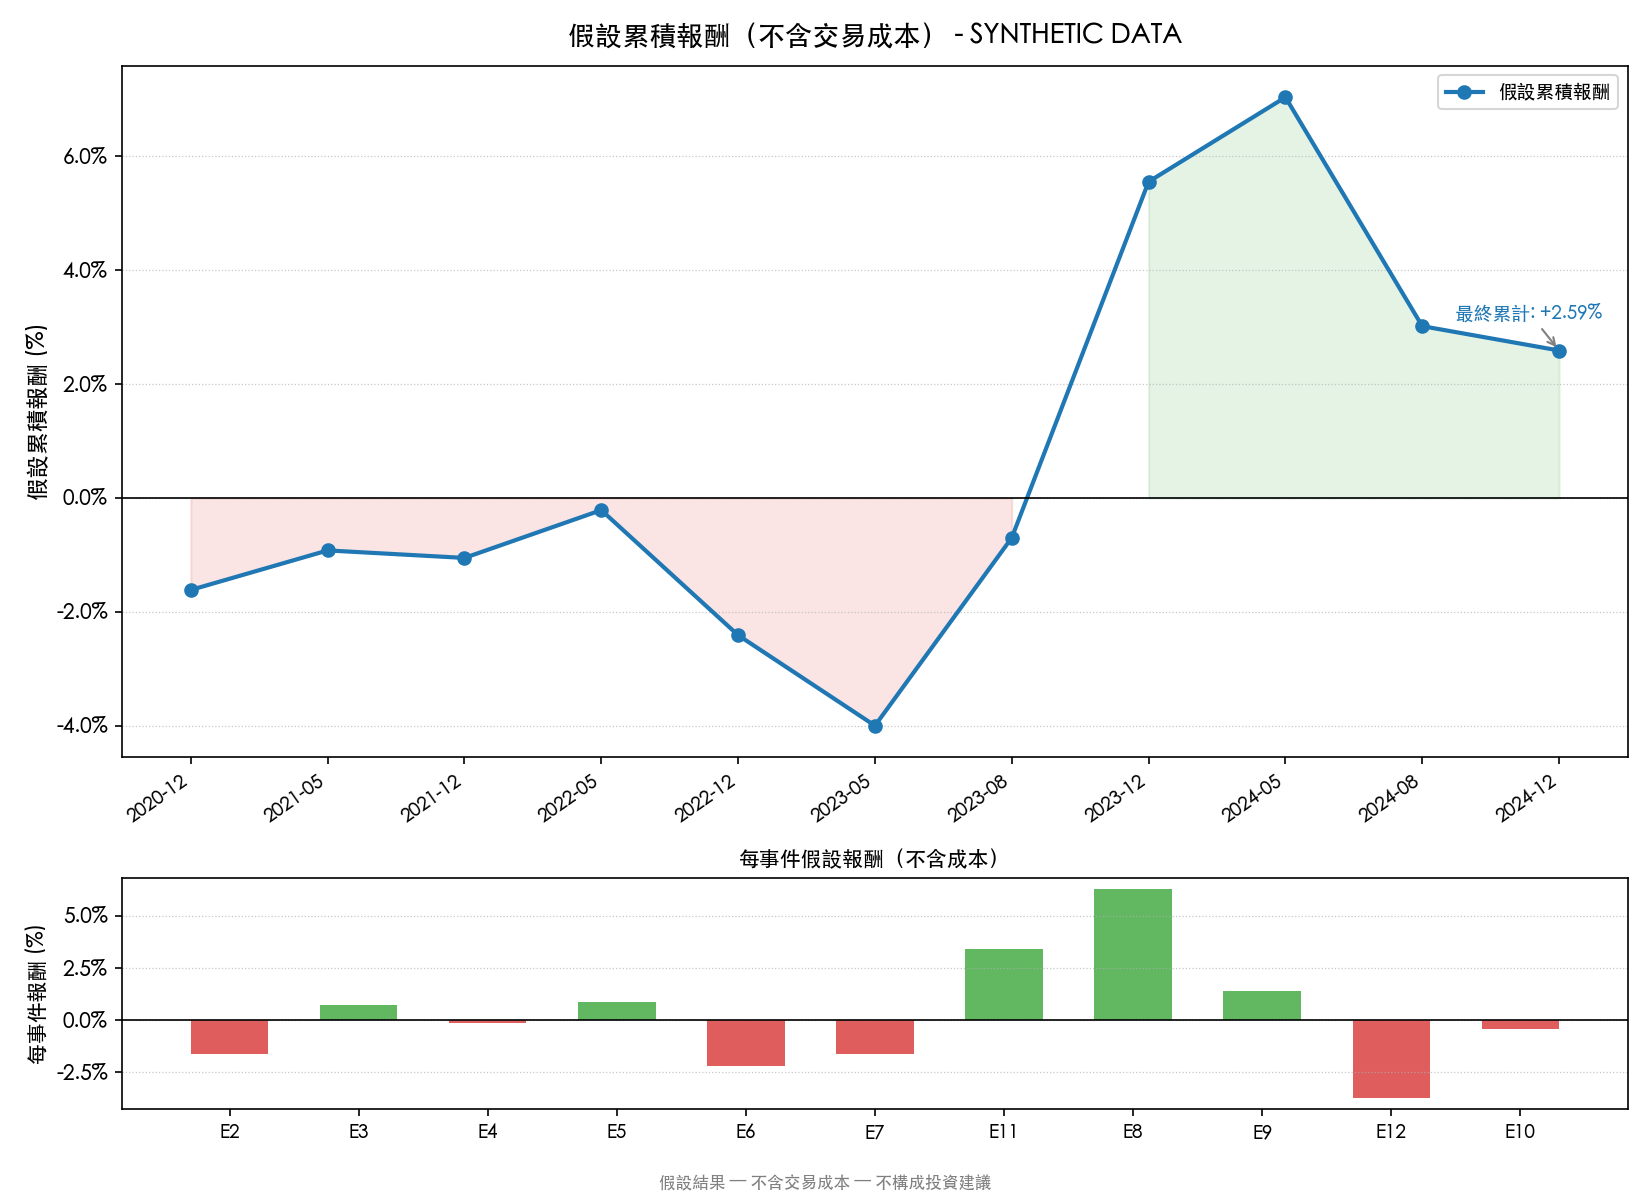

In [9]:
plot_cumulative_return(
    event_returns=event_returns,
    save_path=FIG_DIR / "hypothetical_cumulative_return.png",
    title="假設累積報酬（不含交易成本） - SYNTHETIC DATA",
)

from IPython.display import Image
Image(FIG_DIR / "hypothetical_cumulative_return.png")


## 7. Trade Distribution Analysis

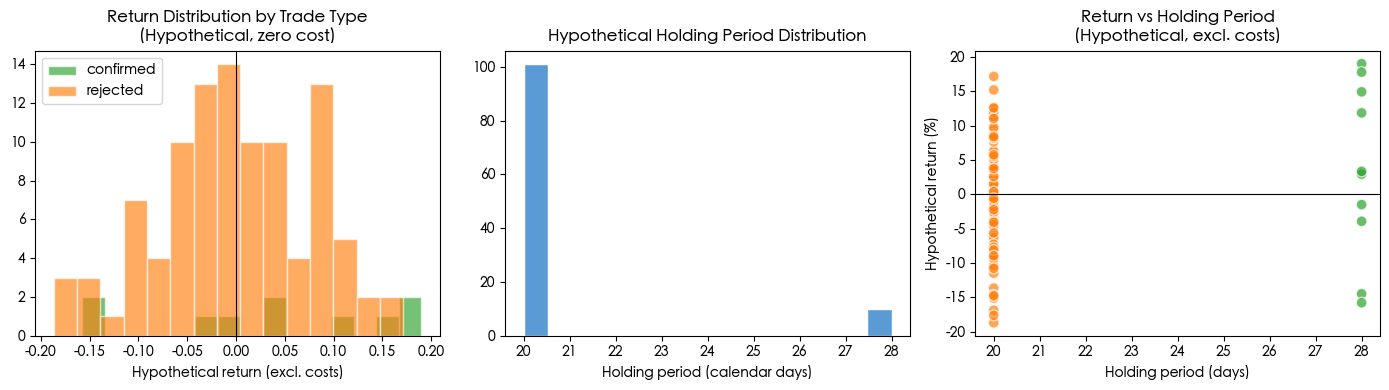

Saved -> hypothetical_trade_analysis.png


In [10]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# (a) Return distribution by trade type
for ttype, color in [("confirmed","#2ca02c"), ("rejected","#ff7f0e")]:
    subset = trades_ret[trades_ret["trade_type"]==ttype]["hypothetical_return"].dropna()
    axes[0].hist(subset, bins=15, alpha=0.65, color=color, label=ttype, edgecolor="white")
axes[0].axvline(0, color="black", lw=0.8)
axes[0].set_xlabel("Hypothetical return (excl. costs)")
axes[0].set_title("Return Distribution by Trade Type\n(Hypothetical, zero cost)")
axes[0].legend()

# (b) Holding-period distribution
trades_ret_v = trades_ret.dropna(subset=["hypothetical_return"]).copy()
trades_ret_v["holding_days"] = (trades_ret_v["exit_date"] - trades_ret_v["entry_date"]).dt.days
axes[1].hist(trades_ret_v["holding_days"], bins=15, color="#5b9bd5", edgecolor="white")
axes[1].set_xlabel("Holding period (calendar days)")
axes[1].set_title("Hypothetical Holding Period Distribution")

# (c) Return vs holding period scatter
axes[2].scatter(
    trades_ret_v["holding_days"],
    trades_ret_v["hypothetical_return"] * 100,
    c=["#2ca02c" if t=="confirmed" else "#ff7f0e"
       for t in trades_ret_v["trade_type"]],
    alpha=0.7, edgecolors="white", s=60,
)
axes[2].axhline(0, color="black", lw=0.8)
axes[2].set_xlabel("Holding period (days)")
axes[2].set_ylabel("Hypothetical return (%)")
axes[2].set_title("Return vs Holding Period\n(Hypothetical, excl. costs)")

plt.tight_layout()
plt.savefig(FIG_DIR / "hypothetical_trade_analysis.png", dpi=150)
plt.show()
print("Saved -> hypothetical_trade_analysis.png")


In [11]:
# Save trades table
trades_ret.to_csv(TABLE_DIR / "hypothetical_trades.csv", index=False)
event_returns.to_csv(TABLE_DIR / "hypothetical_event_returns.csv", index=False)
print("Tables saved.")

print("\n=== Final summary ===")
print(f"  Hypothetical cumul. return : {metrics['hypothetical_cumulative_return']:+.2%}")
print(f"  Hypothetical mean / event  : {metrics['hypothetical_mean_event_return']:+.2%}")
print(f"  Hit rate (events)          : {metrics['hit_rate_events']:.0%}")
print(f"  Max single-event loss      : {metrics['max_single_event_loss']:.2%}")
print(f"  N events                   : {metrics['n_events']}")
print("\n  *** HYPOTHETICAL -- Zero transaction costs assumed ***")


Tables saved.

=== Final summary ===
  Hypothetical cumul. return : +2.59%
  Hypothetical mean / event  : +0.27%
  Hit rate (events)          : 45%
  Max single-event loss      : -3.76%
  N events                   : 11

  *** HYPOTHETICAL -- Zero transaction costs assumed ***


## 8. L/S 策略（假設放空被移除股票）

> **假設**：同一預測日，對預測被移除的股票做空。
> 空頭借券成本、融券限制均**不計入**（過度樂觀假設）。
> 結果僅供訊號強度研究使用。


In [12]:
# ── Removal prediction function ────────────────────────────────────────────
# Predicted removals = stocks in current_constituents NOT in predicted full set
def removal_prediction_func(ref_date, current_constituents):
    if not current_constituents:
        return []
    predicted_full = predict_full_constituents(
        ref_date=ref_date,
        prices_wide=prices_wide,
        per_df=per_df,
        turnover_wide=turnover_wide,
        shares_df=shares_df,
        current_constituents=current_constituents,
        top_k=best_k,
    )
    return list(current_constituents - set(predicted_full))

# ── Generate L/S signals ───────────────────────────────────────────────────
ls_trades = generate_signals_long_short(
    events=events_sorted,
    long_prediction_func=prediction_func,
    short_prediction_func=removal_prediction_func,
    prices_wide=prices_wide,
    signal_date_offset=PRED_OFFSET,
)

print(f"L/S trades: {len(ls_trades)}  "
      f"(long={( ls_trades['direction']=='long').sum()}, "
      f"short={(ls_trades['direction']=='short').sum()})")
print(ls_trades.groupby(['direction','trade_type']).size().to_string())


2026-05-17 22:51:39,568 [WARNING] prediction -- Empty eligible universe at 2020-04-23
2026-05-17 22:51:39,581 [INFO] prediction -- December review: estimated yield approximated as trailing yield (YTD EPS growth data not available).
2026-05-17 22:51:39,635 [INFO] prediction -- December review: estimated yield approximated as trailing yield (YTD EPS growth data not available).
2026-05-17 22:51:39,791 [INFO] prediction -- December review: estimated yield approximated as trailing yield (YTD EPS growth data not available).
2026-05-17 22:51:39,845 [INFO] prediction -- December review: estimated yield approximated as trailing yield (YTD EPS growth data not available).
2026-05-17 22:51:39,996 [INFO] prediction -- December review: estimated yield approximated as trailing yield (YTD EPS growth data not available).
2026-05-17 22:51:40,053 [INFO] prediction -- December review: estimated yield approximated as trailing yield (YTD EPS growth data not available).
2026-05-17 22:51:40,285 [INFO] predict

L/S trades: 194  (long=111, short=83)
direction  trade_type
long       confirmed      10
           rejected      101
short      confirmed       7
           rejected       76


In [13]:
# ── Compute returns and aggregate ─────────────────────────────────────────
ls_trades_ret = compute_trade_returns(ls_trades, prices_wide)
ls_trades_dir = compute_directional_returns(ls_trades_ret)

ls_event_ret = aggregate_long_short_event_returns(ls_trades_dir)

print("=== 假設 L/S 事件報酬（不含成本）===")
print(ls_event_ret[["event_id","ann_date","n_long","n_short",
                     "long_return","short_return","ls_event_return"]].to_string(index=False))

# Summary metrics
er_ls = ls_event_ret["ls_event_return"].dropna()
print(f"\n  假設累積 L/S 報酬 : {float((1+er_ls).prod()-1):+.2%}")
print(f"  假設平均 L/S 報酬 : {float(er_ls.mean()):+.2%}")
print(f"  勝率              : {float((er_ls>0).mean()):.0%}")
print("  (以上為假設值，不含成本、借券費、滑點)")


=== 假設 L/S 事件報酬（不含成本）===
 event_id   ann_date  n_long  n_short  long_return  short_return  ls_event_return
        2 2020-12-09      15        3    -0.016161     -0.006925        -0.014622
        3 2021-05-12      15        5     0.007057     -0.001362         0.004952
        4 2021-12-08      15        8    -0.001330     -0.034156        -0.012748
        5 2022-05-11      14        8     0.008486     -0.013664         0.000432
        6 2022-12-07      12        8    -0.022014      0.003962        -0.011624
        7 2023-05-10      10        8    -0.016290      0.002010        -0.008157
       11 2023-08-09       9        9     0.034382     -0.012970         0.010706
        8 2023-12-06       8        9     0.062983      0.009431         0.034632
        9 2024-05-08       5        8     0.014065     -0.027571        -0.011557
       12 2024-08-07       4        8    -0.037569      0.028704         0.006613
       10 2024-12-04       4        9    -0.004153     -0.028517        -

## 9. 大盤基準比較（假設超額報酬）

以 TAIEX（加權指數）作為被動基準，計算同一持倉窗口的市場報酬。  
假設超額報酬 = 策略假設報酬 − 大盤同期報酬。


In [14]:
# ── Market returns from TAIEX column ──────────────────────────────────────
market_px      = prices_wide["TAIEX"]
market_returns = market_px.pct_change().dropna()

# Per-event benchmark return (same holding window as strategy)
bm_event_ret = compute_benchmark_event_returns(trades, market_returns)

# Merge with strategy event returns
compare_df = event_returns.merge(
    bm_event_ret[["event_id", "benchmark_return"]], on="event_id", how="left"
)
compare_df["excess_return"] = (
    compare_df["hypothetical_event_return"] - compare_df["benchmark_return"]
)

print("=== 假設超額報酬（不含成本）===")
print(compare_df[["event_id","ann_date","hypothetical_event_return",
                   "benchmark_return","excess_return"]].to_string(index=False))
print(f"\n  假設平均超額報酬: {compare_df['excess_return'].mean():+.4%} / event")

# Save comparison
compare_df.to_csv(TABLE_DIR / "hypothetical_strategy_vs_benchmark.csv", index=False)
print("Saved -> output/tables/hypothetical_strategy_vs_benchmark.csv")


=== 假設超額報酬（不含成本）===
 event_id   ann_date  hypothetical_event_return  benchmark_return  excess_return
        2 2020-12-09                  -0.016161          0.025057      -0.041219
        3 2021-05-12                   0.007057         -0.033214       0.040271
        4 2021-12-08                  -0.001330          0.012418      -0.013749
        5 2022-05-11                   0.008486         -0.025182       0.033668
        6 2022-12-07                  -0.022014          0.003722      -0.025737
        7 2023-05-10                  -0.016290         -0.021148       0.004858
       11 2023-08-09                   0.034382          0.012355       0.022027
        8 2023-12-06                   0.062983         -0.042619       0.105602
        9 2024-05-08                   0.014065         -0.024034       0.038098
       12 2024-08-07                  -0.037569          0.039018      -0.076587
       10 2024-12-04                  -0.004153         -0.016042       0.011889

  假設平均超

In [15]:
plot_strategy_vs_benchmark(
    event_returns=event_returns,
    benchmark_event_returns=bm_event_ret,
    save_path=FIG_DIR / "hypothetical_vs_benchmark.png",
)
print("Chart saved -> output/figures/hypothetical_vs_benchmark.png")


2026-05-17 22:51:40,790 [INFO] backtest -- Strategy vs benchmark chart saved -> ../output/figures/hypothetical_vs_benchmark.png


Chart saved -> output/figures/hypothetical_vs_benchmark.png


## 10. 細化假設風險指標

包含：
- **Max Drawdown**：最大回撤（峰谷比）
- **Confirmed vs Rejected** 假設報酬分佈
- **持倉期分佈**（交易日）
- 回撤時序圖


In [16]:
# ── Max drawdown ──────────────────────────────────────────────────────────
max_dd, dd_series = compute_max_drawdown(event_returns)
print(f"假設最大回撤 (Max Drawdown): {max_dd:.2%}")

# ── Holding periods ────────────────────────────────────────────────────────
hp = compute_holding_periods(trades_ret, prices_wide).dropna()
print(f"平均持倉期: {hp.mean():.1f} 交易日")
print(f"中位持倉期: {hp.median():.0f} 交易日")
print(f"最短持倉期: {hp.min():.0f} 交易日")
print(f"最長持倉期: {hp.max():.0f} 交易日")

# ── Win rate breakdown ────────────────────────────────────────────────────
for ttype in ["confirmed", "rejected"]:
    sub = trades_ret.loc[
        trades_ret["trade_type"] == ttype, "hypothetical_return"
    ].dropna()
    if not sub.empty:
        wr = (sub > 0).mean()
        print(f"{ttype:>12}: n={len(sub)}, mean={sub.mean():+.4%}, hit-rate={wr:.0%}")


假設最大回撤 (Max Drawdown): -4.16%
平均持倉期: 14.5 交易日
中位持倉期: 14 交易日
最短持倉期: 14 交易日
最長持倉期: 20 交易日
   confirmed: n=10, mean=+3.4133%, hit-rate=60%
    rejected: n=101, mean=-0.0885%, hit-rate=50%


In [17]:
plot_risk_breakdown(
    trades_with_returns=trades_ret,
    event_returns=event_returns,
    prices_wide=prices_wide,
    save_path=FIG_DIR / "hypothetical_risk_breakdown.png",
)
print("Chart saved -> output/figures/hypothetical_risk_breakdown.png")


2026-05-17 22:51:41,167 [INFO] backtest -- Risk breakdown chart saved -> ../output/figures/hypothetical_risk_breakdown.png


Chart saved -> output/figures/hypothetical_risk_breakdown.png


## 11. 假設參數敏感度：signal_date_offset

掃描 `signal_date_offset` ∈ {−7, −10, −14, −17, −21} 交易日，  
觀察對預測精確率、召回率，以及假設報酬的影響。  
**所有結果均為假設值，不含成本。**


In [18]:
# ── Parameter sweep ───────────────────────────────────────────────────────
OFFSETS = [-7, -10, -14, -17, -21]
sweep_rows = []

for offset in OFFSETS:
    # Prediction metrics (OOS = test split, same 60/40 split as notebook 04)
    bt = backtest_predictions(
        events=events_sorted,
        prices_wide=prices_wide,
        per_df=per_df,
        turnover_wide=turnover_wide,
        shares_df=shares_df,
        prediction_date_offset=offset,
        top_k=best_k,
    )
    test_rows = bt[~bt["event_id"].isin(train_event_ids)]
    mean_prec = test_rows["precision"].mean() if not test_rows.empty else np.nan
    mean_rec  = test_rows["recall"].mean()    if not test_rows.empty else np.nan
    mean_f1   = test_rows["f1"].mean()        if not test_rows.empty else np.nan

    # Hypothetical return with this offset
    sig = generate_signals(
        events=events_sorted,
        prediction_func=prediction_func,
        prices_wide=prices_wide,
        signal_date_offset=offset,
    )
    if sig.empty:
        hyp_ret = np.nan
    else:
        tr  = compute_trade_returns(sig, prices_wide)
        er_ = aggregate_event_returns(tr)
        hyp_ret = er_["hypothetical_event_return"].mean() if not er_.empty else np.nan

    sweep_rows.append({
        "offset":                  offset,
        "precision":               mean_prec,
        "recall":                  mean_rec,
        "f1":                      mean_f1,
        "hypothetical_mean_return": hyp_ret,
    })
    print(f"offset={offset:4d}: precision={mean_prec:.3f}, recall={mean_rec:.3f}, "
          f"f1={mean_f1:.3f}, hyp_return={hyp_ret:+.4%}")

sensitivity_df = pd.DataFrame(sweep_rows)
sensitivity_df.to_csv(TABLE_DIR / "parameter_sensitivity.csv", index=False)
print("\nSaved -> output/tables/parameter_sensitivity.csv")


2026-05-17 22:51:41,180 [WARNING] prediction -- Empty eligible universe at 2020-05-04
2026-05-17 22:51:41,180 [INFO] prediction -- Event 1  pred=2020-05-04  ann=2020-05-13  precision=0.00  recall=0.00
2026-05-17 22:51:41,198 [INFO] prediction -- December review: estimated yield approximated as trailing yield (YTD EPS growth data not available).
2026-05-17 22:51:41,238 [INFO] prediction -- Event 2  pred=2020-11-30  ann=2020-12-09  precision=0.00  recall=0.00
2026-05-17 22:51:41,294 [INFO] prediction -- Event 3  pred=2021-05-03  ann=2021-05-12  precision=0.00  recall=0.00
2026-05-17 22:51:41,311 [INFO] prediction -- December review: estimated yield approximated as trailing yield (YTD EPS growth data not available).
2026-05-17 22:51:41,351 [INFO] prediction -- Event 4  pred=2021-11-29  ann=2021-12-08  precision=0.00  recall=0.00
2026-05-17 22:51:41,402 [INFO] prediction -- Event 5  pred=2022-05-02  ann=2022-05-11  precision=0.13  recall=0.67
2026-05-17 22:51:41,417 [INFO] prediction -- De

offset=  -7: precision=0.261, recall=0.458, f1=0.323, hyp_return=+0.5379%


2026-05-17 22:51:42,441 [INFO] prediction -- Event 5  pred=2022-04-27  ann=2022-05-11  precision=0.14  recall=0.67
2026-05-17 22:51:42,457 [INFO] prediction -- December review: estimated yield approximated as trailing yield (YTD EPS growth data not available).
2026-05-17 22:51:42,494 [INFO] prediction -- Event 6  pred=2022-11-23  ann=2022-12-07  precision=0.00  recall=0.00
2026-05-17 22:51:42,541 [INFO] prediction -- Event 7  pred=2023-04-26  ann=2023-05-10  precision=0.10  recall=0.25
2026-05-17 22:51:42,588 [INFO] prediction -- Event 11  pred=2023-07-26  ann=2023-08-09  precision=0.22  recall=1.00
2026-05-17 22:51:42,603 [INFO] prediction -- December review: estimated yield approximated as trailing yield (YTD EPS growth data not available).
2026-05-17 22:51:42,637 [INFO] prediction -- Event 8  pred=2023-11-22  ann=2023-12-06  precision=0.14  recall=0.50
2026-05-17 22:51:42,684 [INFO] prediction -- Event 9  pred=2024-04-24  ann=2024-05-08  precision=0.33  recall=0.67
2026-05-17 22:51:

offset= -10: precision=0.244, recall=0.458, f1=0.310, hyp_return=+1.0131%


2026-05-17 22:51:43,536 [INFO] prediction -- Event 5  pred=2022-04-21  ann=2022-05-11  precision=0.14  recall=0.67
2026-05-17 22:51:43,551 [INFO] prediction -- December review: estimated yield approximated as trailing yield (YTD EPS growth data not available).
2026-05-17 22:51:43,586 [INFO] prediction -- Event 6  pred=2022-11-17  ann=2022-12-07  precision=0.00  recall=0.00
2026-05-17 22:51:43,631 [INFO] prediction -- Event 7  pred=2023-04-20  ann=2023-05-10  precision=0.10  recall=0.25
2026-05-17 22:51:43,677 [INFO] prediction -- Event 11  pred=2023-07-20  ann=2023-08-09  precision=0.22  recall=1.00
2026-05-17 22:51:43,692 [INFO] prediction -- December review: estimated yield approximated as trailing yield (YTD EPS growth data not available).
2026-05-17 22:51:43,725 [INFO] prediction -- Event 8  pred=2023-11-16  ann=2023-12-06  precision=0.12  recall=0.50
2026-05-17 22:51:43,770 [INFO] prediction -- Event 9  pred=2024-04-18  ann=2024-05-08  precision=0.40  recall=0.67
2026-05-17 22:51:

offset= -14: precision=0.256, recall=0.458, f1=0.318, hyp_return=+0.2678%


2026-05-17 22:51:44,628 [INFO] prediction -- December review: estimated yield approximated as trailing yield (YTD EPS growth data not available).
2026-05-17 22:51:44,660 [INFO] prediction -- Event 6  pred=2022-11-14  ann=2022-12-07  precision=0.00  recall=0.00
2026-05-17 22:51:44,703 [INFO] prediction -- Event 7  pred=2023-04-17  ann=2023-05-10  precision=0.10  recall=0.25
2026-05-17 22:51:44,745 [INFO] prediction -- Event 11  pred=2023-07-17  ann=2023-08-09  precision=0.22  recall=1.00
2026-05-17 22:51:44,758 [INFO] prediction -- December review: estimated yield approximated as trailing yield (YTD EPS growth data not available).
2026-05-17 22:51:44,789 [INFO] prediction -- Event 8  pred=2023-11-13  ann=2023-12-06  precision=0.14  recall=0.50
2026-05-17 22:51:44,832 [INFO] prediction -- Event 9  pred=2024-04-15  ann=2024-05-08  precision=0.29  recall=0.67
2026-05-17 22:51:44,878 [INFO] prediction -- Event 12  pred=2024-07-15  ann=2024-08-07  precision=0.67  recall=0.67
2026-05-17 22:51

offset= -17: precision=0.274, recall=0.458, f1=0.322, hyp_return=+0.7100%


2026-05-17 22:51:45,703 [INFO] prediction -- Event 5  pred=2022-04-12  ann=2022-05-11  precision=0.21  recall=1.00
2026-05-17 22:51:45,718 [INFO] prediction -- December review: estimated yield approximated as trailing yield (YTD EPS growth data not available).
2026-05-17 22:51:45,755 [INFO] prediction -- Event 6  pred=2022-11-08  ann=2022-12-07  precision=0.00  recall=0.00
2026-05-17 22:51:45,802 [INFO] prediction -- Event 7  pred=2023-04-11  ann=2023-05-10  precision=0.18  recall=0.50
2026-05-17 22:51:45,849 [INFO] prediction -- Event 11  pred=2023-07-11  ann=2023-08-09  precision=0.22  recall=1.00
2026-05-17 22:51:45,865 [INFO] prediction -- December review: estimated yield approximated as trailing yield (YTD EPS growth data not available).
2026-05-17 22:51:45,900 [INFO] prediction -- Event 8  pred=2023-11-07  ann=2023-12-06  precision=0.12  recall=0.50
2026-05-17 22:51:45,947 [INFO] prediction -- Event 9  pred=2024-04-09  ann=2024-05-08  precision=0.40  recall=0.67
2026-05-17 22:51:

offset= -21: precision=0.256, recall=0.458, f1=0.318, hyp_return=+0.6706%

Saved -> output/tables/parameter_sensitivity.csv


In [19]:
plot_parameter_sensitivity(
    sensitivity_df=sensitivity_df,
    save_path=FIG_DIR / "hypothetical_parameter_sensitivity.png",
)
print("Chart saved -> output/figures/hypothetical_parameter_sensitivity.png")


2026-05-17 22:51:46,756 [INFO] backtest -- Parameter sensitivity chart saved -> ../output/figures/hypothetical_parameter_sensitivity.png


Chart saved -> output/figures/hypothetical_parameter_sensitivity.png


## Appendix: Methodological Caveats

| Assumption | Effect | Direction of bias |
|-----------|--------|-------------------|
| Zero transaction costs | Overstates net returns | Upward |
| Execution at closing price | Requires prediction before market open on entry day | Optimistic |
| No market impact | ETF rebalancing flows would move prices against our positions | Upward |
| Equal-weight positions | Simplification; real sizing would consider risk | Neutral |
| Prediction model uses trailing yield (Dec reviews) | Misses EPS growth adjustment | Mixed |
| Incomplete stock universe | Prediction quality understated vs full universe | Downward (conservative) |

**Interpretation guide**: The hypothetical cumulative return measures how much of the
reconstitution price effect our prediction model can *theoretically* capture if executed
under ideal conditions. A positive result confirms signal existence, but real-world
net returns after costs would be substantially lower.
